In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP 1: Load discriminative neurons from all layers
# ============================================================

# Load all layer activations and identify discriminative neurons
all_layers = [3, 6, 9, 12]
discriminative_activations = []
neuron_info = []  # Track which layer each neuron comes from

for layer in all_layers:
    # Load neuron stats to identify discriminative neurons
    stats_df = pd.read_csv(f'../results/activations/layer_{layer}_neuron_stats.csv')
    discriminative_mask = stats_df['discriminative'].values
    discriminative_indices = np.where(discriminative_mask)[0]
    
    # Load activations for this layer
    layer_activations = np.load(f'../results/activations/layer_{layer}_activations.npy')
    
    # Extract only discriminative neurons
    layer_disc_activations = layer_activations[:, discriminative_indices]
    discriminative_activations.append(layer_disc_activations)
    
    # Track neuron info (layer and original index)
    for idx in discriminative_indices:
        neuron_info.append({'layer': layer, 'neuron_idx': idx})
    
    print(f"Layer {layer}: {len(discriminative_indices)} discriminative neurons")

# Concatenate all discriminative neurons across layers
# Shape: (n_samples, total_discriminative_neurons)
all_discriminative_activations = np.concatenate(discriminative_activations, axis=1)
neuron_info_df = pd.DataFrame(neuron_info)

print(f"\nTotal discriminative neurons across all layers: {all_discriminative_activations.shape[1]}")
print(f"Number of samples: {all_discriminative_activations.shape[0]}")

# ============================================================
# STEP 2: Compute Correlation Matrix
# ============================================================

# Transpose to get (n_neurons, n_samples) for correlation computation
activation_matrix = all_discriminative_activations.T

# Spearman correlation between all neuron pairs
corr_matrix, _ = spearmanr(activation_matrix, axis=1)

# Convert correlation to distance
# Important: Use 1 - abs(corr) so both positive and negative correlations
# indicate similarity (both mean neurons co-activate, just with opposite polarity)
distance_matrix = 1 - np.abs(corr_matrix)

# ============================================================
# STEP 3: Hierarchical Clustering with Average Linkage
# ============================================================

# Convert full distance matrix to condensed form for linkage
# (linkage expects upper triangle only)
condensed_dist = squareform(distance_matrix, checks=False)

# Compute linkage with AVERAGE method (best for correlation)
Z = linkage(condensed_dist, method='average')


Layer 3: 108 discriminative neurons
Layer 6: 112 discriminative neurons
Layer 9: 110 discriminative neurons
Layer 12: 186 discriminative neurons

Total discriminative neurons across all layers: 516
Number of samples: 1000


In [35]:
Z

array([[3.99000000e+02, 4.34000000e+02, 1.95008271e-01, 2.00000000e+00],
       [8.00000000e+00, 6.70000000e+01, 2.04547340e-01, 2.00000000e+00],
       [2.65000000e+02, 4.00000000e+02, 2.14686899e-01, 2.00000000e+00],
       ...,
       [1.02100000e+03, 1.02400000e+03, 7.93813064e-01, 2.55000000e+02],
       [1.02600000e+03, 1.02800000e+03, 8.08210927e-01, 2.61000000e+02],
       [1.02700000e+03, 1.02900000e+03, 1.31108336e+00, 5.16000000e+02]],
      shape=(515, 4))

K=2 CLUSTER COMPOSITION BY LAYER

Cluster 1 (n=255):
layer
12    88
6     57
9     56
3     54
Name: count, dtype: int64

Cluster 2 (n=261):
layer
12    98
6     55
3     54
9     54
Name: count, dtype: int64


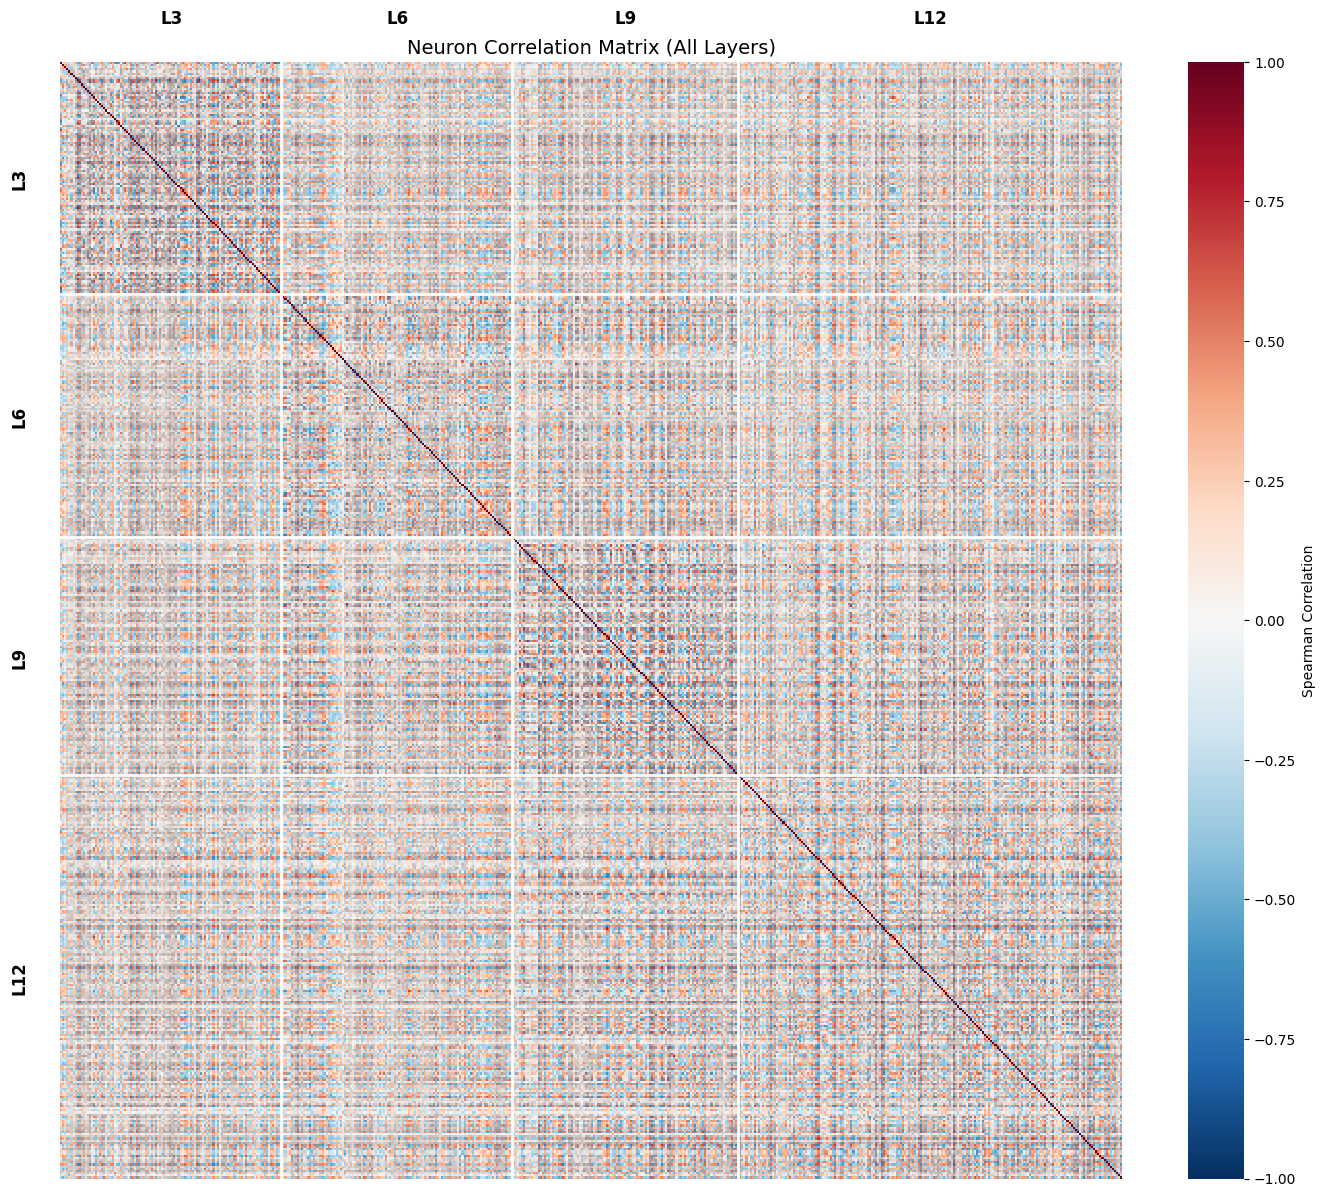


CORRELATION STATISTICS
Within-layer mean |correlation|: 0.338
Between-layer mean |correlation|: 0.302
Difference: 0.037


In [36]:
# ============================================================
# DIAGNOSTIC 1: Check what the 99-1% split actually is
# ============================================================

labels_k2 = fcluster(Z, 2, criterion='maxclust')

# Which layers are in each cluster?
cluster_1_layers = neuron_info_df[labels_k2 == 1]['layer'].value_counts()
cluster_2_layers = neuron_info_df[labels_k2 == 2]['layer'].value_counts()

print("=" * 60)
print("K=2 CLUSTER COMPOSITION BY LAYER")
print("=" * 60)
print(f"\nCluster 1 (n={np.sum(labels_k2 == 1)}):")
print(cluster_1_layers)
print(f"\nCluster 2 (n={np.sum(labels_k2 == 2)}):")
print(cluster_2_layers)

# ============================================================
# DIAGNOSTIC 2: Correlation matrix visualization
# ============================================================

# Add layer labels for visualization
neuron_layers = neuron_info_df['layer'].values

# Create correlation heatmap with layer boundaries
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, 
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Spearman Correlation'})

# Add layer boundaries
layer_boundaries = []
cumsum = 0
for layer in [3, 6, 9, 12]:
    count = np.sum(neuron_layers == layer)
    cumsum += count
    layer_boundaries.append(cumsum)
    if cumsum < len(neuron_layers):  # Don't draw line at the end
        ax.axhline(cumsum - 0.5, color='white', linewidth=2)
        ax.axvline(cumsum - 0.5, color='white', linewidth=2)

# Add layer labels
layer_positions = [0]
for i, boundary in enumerate(layer_boundaries):
    if i == 0:
        pos = boundary / 2
    else:
        pos = (layer_boundaries[i-1] + boundary) / 2
    ax.text(pos, -20, f'L{[3,6,9,12][i]}', ha='center', va='center', 
            fontsize=12, fontweight='bold')
    ax.text(-20, pos, f'L{[3,6,9,12][i]}', ha='center', va='center', 
            fontsize=12, fontweight='bold', rotation=90)

plt.title('Neuron Correlation Matrix (All Layers)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap_all_layers.pdf', dpi=300)
plt.show()

# ============================================================
# DIAGNOSTIC 3: Correlation statistics
# ============================================================

# Within-layer vs between-layer correlations
within_layer_corrs = []
between_layer_corrs = []

for i in range(len(neuron_layers)):
    for j in range(i+1, len(neuron_layers)):
        if neuron_layers[i] == neuron_layers[j]:
            within_layer_corrs.append(corr_matrix[i, j])
        else:
            between_layer_corrs.append(corr_matrix[i, j])

print("\n" + "=" * 60)
print("CORRELATION STATISTICS")
print("=" * 60)
print(f"Within-layer mean |correlation|: {np.mean(np.abs(within_layer_corrs)):.3f}")
print(f"Between-layer mean |correlation|: {np.mean(np.abs(between_layer_corrs)):.3f}")
print(f"Difference: {np.mean(np.abs(within_layer_corrs)) - np.mean(np.abs(between_layer_corrs)):.3f}")

# If between-layer correlations are much lower, layers dominate the clustering

In [41]:
# # ============================================================
# # STEP 3: Visualize Dendrogram
# # ============================================================

# plt.figure(figsize=(15, 8))
# dendrogram(
#     Z,
#     no_labels=True,  # Too many neurons to show labels
#     color_threshold=0.4,  # Color clusters below this threshold differently
#     above_threshold_color='gray'
# )
# plt.title('Hierarchical Clustering Dendrogram (Average Linkage)', fontsize=14)
# plt.xlabel('Neuron Index', fontsize=12)
# plt.ylabel('Distance (1 - |correlation|)', fontsize=12)
# plt.axhline(y=0.3, color='red', linestyle='--', linewidth=2, label='Cut at 0.3')
# plt.axhline(y=0.4, color='orange', linestyle='--', linewidth=2, label='Cut at 0.4')
# plt.axhline(y=0.5, color='green', linestyle='--', linewidth=2, label='Cut at 0.5')
# plt.legend()
# plt.tight_layout()
# plt.savefig('dendrogram_average_linkage.pdf', dpi=300)
# plt.show()

In [42]:
# ============================================================
# STEP 4: Determine Optimal k via Multiple Metrics
# ============================================================

k_range = range(2, 11)
metrics = {
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

for k in k_range:
    labels = fcluster(Z, k, criterion='maxclust')
    
    # Silhouette on precomputed distance
    sil = silhouette_score(distance_matrix, labels, metric='precomputed')
    
    # DB and CH need Euclidean - use correlation matrix as features
    db = davies_bouldin_score(corr_matrix, labels)
    ch = calinski_harabasz_score(corr_matrix, labels)
    
    metrics['silhouette'].append(sil)
    metrics['davies_bouldin'].append(db)
    metrics['calinski_harabasz'].append(ch)
    
    print(f"k={k}: Silhouette={sil:.3f}, davies_bouldin={db:.3f}, calinski_harabasz={ch:.1f}, "
          f"Sizes={np.bincount(labels)}")

k=2: Silhouette=0.471, davies_bouldin=0.368, calinski_harabasz=3612.3, Sizes=[  0 255 261]
k=3: Silhouette=0.280, davies_bouldin=1.010, calinski_harabasz=1840.2, Sizes=[  0 255   6 255]
k=4: Silhouette=0.255, davies_bouldin=1.354, calinski_harabasz=1234.3, Sizes=[  0 255   6 252   3]
k=5: Silhouette=0.111, davies_bouldin=1.649, calinski_harabasz=936.2, Sizes=[  0   6 249   6 252   3]
k=6: Silhouette=0.101, davies_bouldin=1.480, calinski_harabasz=748.4, Sizes=[  0   6 249   5   1 252   3]
k=7: Silhouette=0.086, davies_bouldin=1.536, calinski_harabasz=637.3, Sizes=[  0   6  11 238   5   1 252   3]
k=8: Silhouette=0.069, davies_bouldin=1.411, calinski_harabasz=545.9, Sizes=[  0   6  11 238   5   1 252   2   1]
k=9: Silhouette=0.061, davies_bouldin=1.344, calinski_harabasz=477.2, Sizes=[  0   5   1  11 238   5   1 252   2   1]
k=10: Silhouette=0.050, davies_bouldin=1.366, calinski_harabasz=425.9, Sizes=[  0   5   1  11   3 235   5   1 252   2   1]


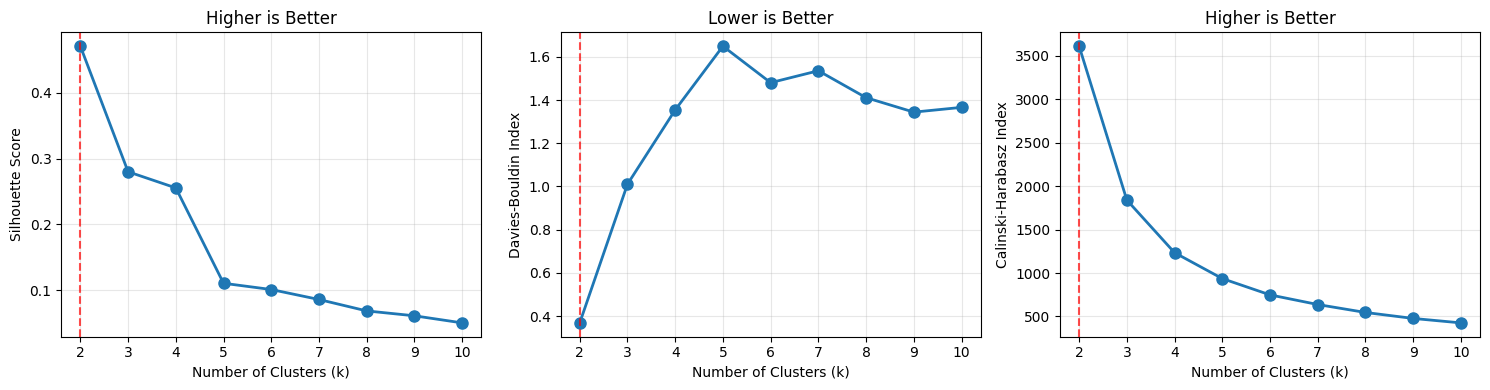

In [43]:
# Plot validation metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, metrics['silhouette'], 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Higher is Better')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(k_range[np.argmax(metrics['silhouette'])], 
                color='red', linestyle='--', alpha=0.7)

axes[1].plot(k_range, metrics['davies_bouldin'], 'o-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Lower is Better')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(k_range[np.argmin(metrics['davies_bouldin'])], 
                color='red', linestyle='--', alpha=0.7)

axes[2].plot(k_range, metrics['calinski_harabasz'], 'o-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Index')
axes[2].set_title('Higher is Better')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(k_range[np.argmax(metrics['calinski_harabasz'])], 
                color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('clustering_validation_metrics.pdf', dpi=300)
plt.show()

In [44]:
# ============================================================
# STEP 5: Final Clustering with Optimal k
# ============================================================

optimal_k = k_range[np.argmax(metrics['silhouette'])]
final_labels = fcluster(Z, optimal_k, criterion='maxclust')

print(f"\n{'='*60}")
print(f"OPTIMAL CLUSTERING: k={optimal_k}")
print(f"{'='*60}")

for cluster_id in range(1, optimal_k + 1):
    size = np.sum(final_labels == cluster_id)
    print(f"Cluster {cluster_id}: {size} neurons ({size/Z.shape[0]*100:.1f}%)")


OPTIMAL CLUSTERING: k=2
Cluster 1: 255 neurons (49.5%)
Cluster 2: 261 neurons (50.7%)
